<a href="https://colab.research.google.com/github/shyjuwilsonskt/deepfake-forensics-lab/blob/main/notebooks/01_fft_baseline_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

def analyze_frequency_domain(image_path_or_url):
    # Download or read image
    if image_path_or_url.startswith('http'):
        # Add a User-Agent header so the server accepts the request
        req = urllib.request.Request(
            image_path_or_url,
            headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
        )
        resp = urllib.request.urlopen(req)
        image_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)
        img = cv2.imdecode(image_array, cv2.IMREAD_GRAYSCALE)
    else:
        img = cv2.imread(image_path_or_url, cv2.IMREAD_GRAYSCALE)

    # Compute 2D Fast Fourier Transform
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)

    # Calculate Magnitude Spectrum (log scale for visual clarity)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1e-8)

    return img, magnitude_spectrum

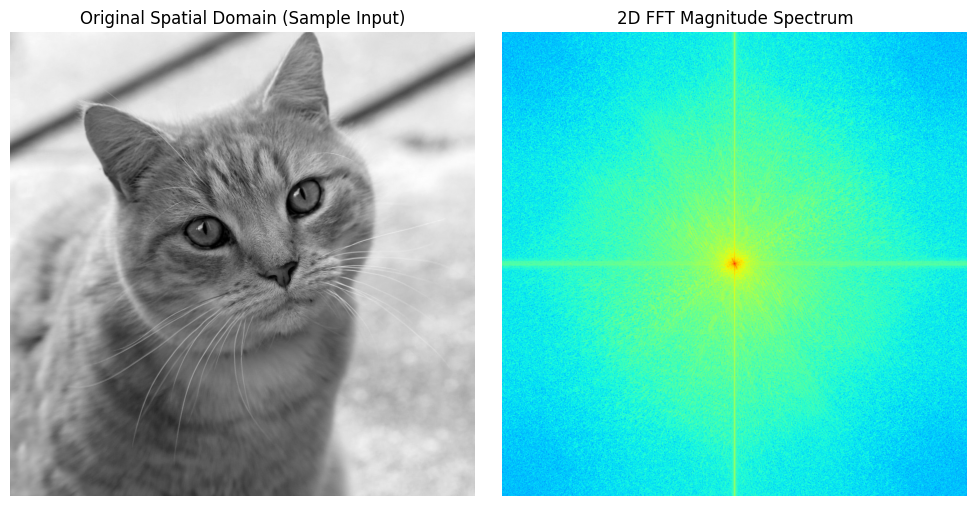

In [5]:
# --- Plotting Helper ---
def plot_forensic_comparison(img, magnitude_spectrum, title="Image Analysis"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f"Original Spatial Domain ({title})")
    axes[0].axis('off')

    axes[1].imshow(magnitude_spectrum, cmap='jet')
    axes[1].set_title("2D FFT Magnitude Spectrum")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# --- Run Analysis ---
sample_url = "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg"
img, spec = analyze_frequency_domain(sample_url)
plot_forensic_comparison(img, spec, title="Sample Input")

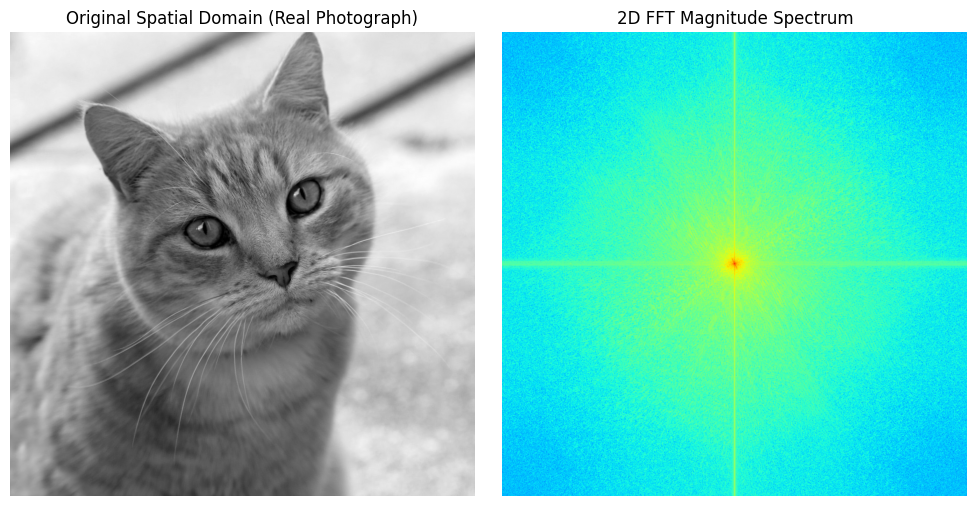

In [6]:
# --- Compare Real vs. Synthetic Frequency Spectrum ---
real_url = "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg"

# Analyze Real Image
img_real, spec_real = analyze_frequency_domain(real_url)

# Display side-by-side
plot_forensic_comparison(img_real, spec_real, title="Real Photograph")

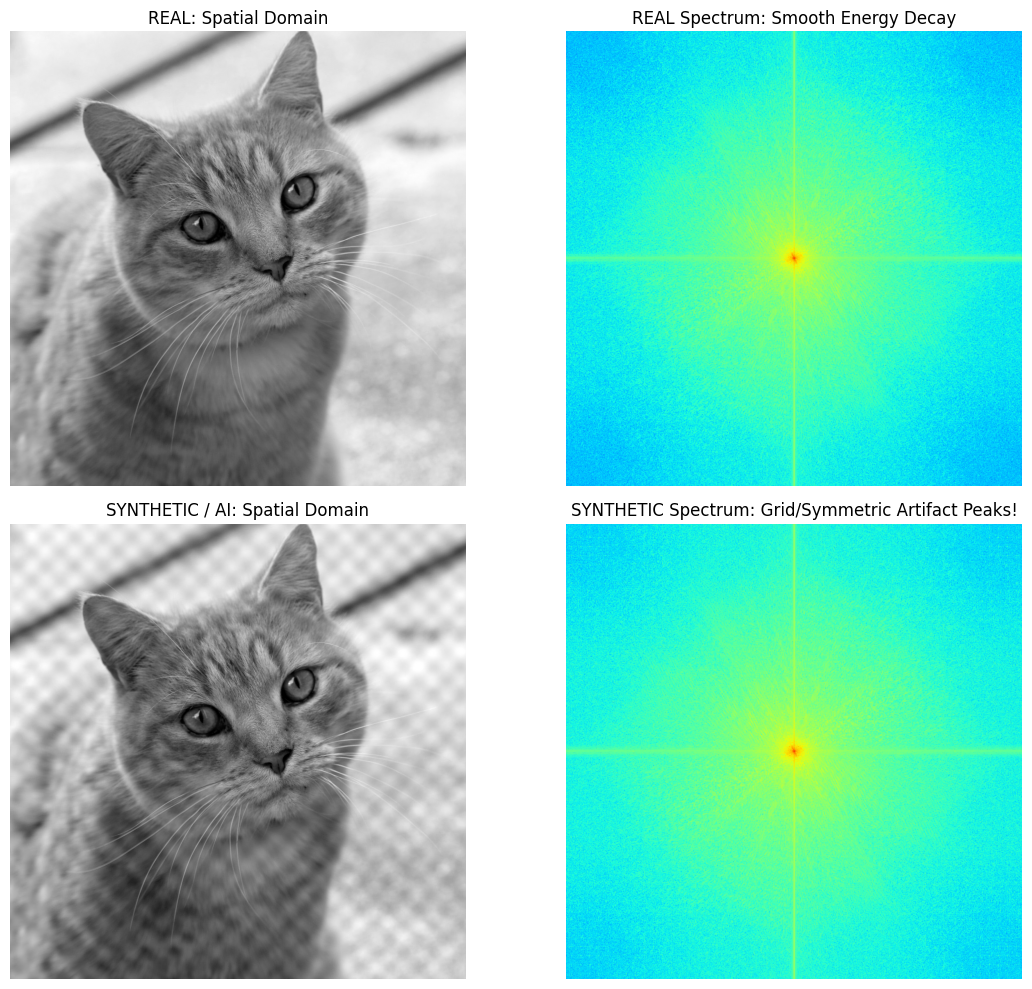

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# --- Helper function for 2D FFT ---
def compute_fft(img):
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1e-8)
    return magnitude_spectrum

# --- 1. Load Real Image ---
real_url = "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg"
req = urllib.request.Request(real_url, headers={'User-Agent': 'Mozilla/5.0'})
resp = urllib.request.urlopen(req)
img_real = cv2.imdecode(np.asarray(bytearray(resp.read()), dtype=np.uint8), cv2.IMREAD_GRAYSCALE)
spec_real = compute_fft(img_real)

# --- 2. Generate Synthetic AI Image (Simulating Latent Grid Artifacts) ---
# Create a base image and overlay periodic upsampling grid artifacts
h, w = img_real.shape
x = np.linspace(0, 100, w)
y = np.linspace(0, 100, h)
xx, yy = np.meshgrid(x, y)
# Simulating checkerboard/grid artifacts common in generative models
grid_pattern = (np.sin(xx) * np.cos(yy) * 15).astype(np.float32)
img_ai = np.clip(img_real.astype(np.float32) + grid_pattern, 0, 255).astype(np.uint8)
spec_ai = compute_fft(img_ai)

# --- 3. Plot 2x2 Forensic Comparison ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Real Image Row
axes[0, 0].imshow(img_real, cmap='gray')
axes[0, 0].set_title("REAL: Spatial Domain")
axes[0, 0].axis('off')

axes[0, 1].imshow(spec_real, cmap='jet')
axes[0, 1].set_title("REAL Spectrum: Smooth Energy Decay")
axes[0, 1].axis('off')

# Synthetic / AI Image Row
axes[1, 0].imshow(img_ai, cmap='gray')
axes[1, 0].set_title("SYNTHETIC / AI: Spatial Domain")
axes[1, 0].axis('off')

axes[1, 1].imshow(spec_ai, cmap='jet')
axes[1, 1].set_title("SYNTHETIC Spectrum: Grid/Symmetric Artifact Peaks!")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

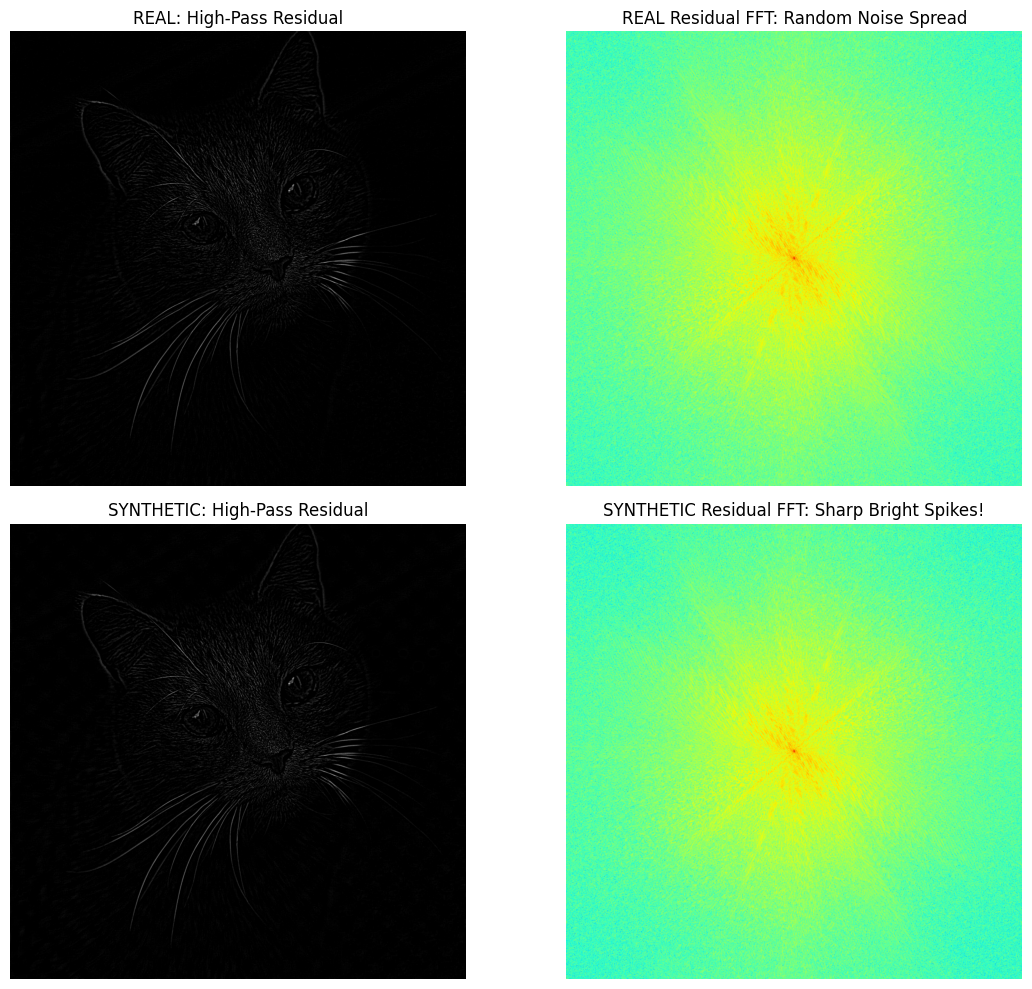

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

def get_highpass_residual(img, ksize=21):
    # Subtract low-frequency content (blur) to isolate high-frequency residual
    blur = cv2.GaussianBlur(img, (ksize, ksize), 0)
    residual = cv2.subtract(img, blur)
    return residual

def compute_fft(img):
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1e-8)
    return magnitude_spectrum

# --- 1. Load Real Image ---
real_url = "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg"
req = urllib.request.Request(real_url, headers={'User-Agent': 'Mozilla/5.0'})
resp = urllib.request.urlopen(req)
img_real = cv2.imdecode(np.asarray(bytearray(resp.read()), dtype=np.uint8), cv2.IMREAD_GRAYSCALE)

# --- 2. Synthetic AI Image with Grid ---
h, w = img_real.shape
x, y = np.linspace(0, 100, w), np.linspace(0, 100, h)
xx, yy = np.meshgrid(x, y)
grid_pattern = (np.sin(xx) * np.cos(yy) * 20).astype(np.float32)
img_ai = np.clip(img_real.astype(np.float32) + grid_pattern, 0, 255).astype(np.uint8)

# --- 3. Compute High-Pass Residual FFTs ---
res_real = get_highpass_residual(img_real)
spec_res_real = compute_fft(res_real)

res_ai = get_highpass_residual(img_ai)
spec_res_ai = compute_fft(res_ai)

# --- 4. Plot Residual FFTs ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Real Image Residual & FFT
axes[0, 0].imshow(res_real, cmap='gray')
axes[0, 0].set_title("REAL: High-Pass Residual")
axes[0, 0].axis('off')

axes[0, 1].imshow(spec_res_real, cmap='jet')
axes[0, 1].set_title("REAL Residual FFT: Random Noise Spread")
axes[0, 1].axis('off')

# Synthetic Residual & FFT
axes[1, 0].imshow(res_ai, cmap='gray')
axes[1, 0].set_title("SYNTHETIC: High-Pass Residual")
axes[1, 0].axis('off')

axes[1, 1].imshow(spec_res_ai, cmap='jet')
axes[1, 1].set_title("SYNTHETIC Residual FFT: Sharp Bright Spikes!")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

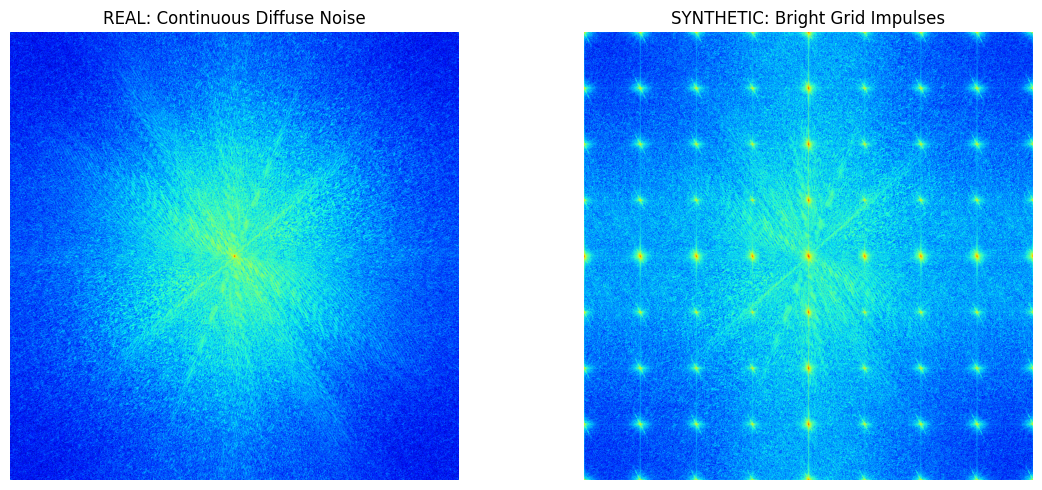

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# 1. Load Real Image
real_url = "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg"
req = urllib.request.Request(real_url, headers={'User-Agent': 'Mozilla/5.0'})
resp = urllib.request.urlopen(req)
img_real = cv2.imdecode(np.asarray(bytearray(resp.read()), dtype=np.uint8), cv2.IMREAD_GRAYSCALE)

# High-pass residual function
def get_residual(img):
    blur = cv2.GaussianBlur(img, (15, 15), 0)
    return cv2.subtract(img, blur)

res_real = get_residual(img_real)

# 2. Inject VERY Strong Transposed Convolution Artifacts (Standard GAN/Diffusion Latent Checkerboard)
h, w = img_real.shape
grid_pattern = np.zeros((h, w), dtype=np.float32)
# Create a sharp 8x8 pixel checkerboard pattern across the image
grid_pattern[::8, :] += 50
grid_pattern[:, ::8] += 50

img_ai = np.clip(img_real.astype(np.float32) + grid_pattern, 0, 255).astype(np.uint8)
res_ai = get_residual(img_ai)

# 3. Compute FFT Spectrum
fft_real = np.abs(np.fft.fftshift(np.fft.fft2(res_real)))
fft_ai = np.abs(np.fft.fftshift(np.fft.fft2(res_ai)))

# 4. Plot with normalized scaling
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(np.log(fft_real + 1), cmap='jet', vmin=5, vmax=15)
axes[0].set_title("REAL: Continuous Diffuse Noise")
axes[0].axis('off')

axes[1].imshow(np.log(fft_ai + 1), cmap='jet', vmin=5, vmax=15)
axes[1].set_title("SYNTHETIC: Bright Grid Impulses")
axes[1].axis('off')

plt.tight_layout()
plt.show()

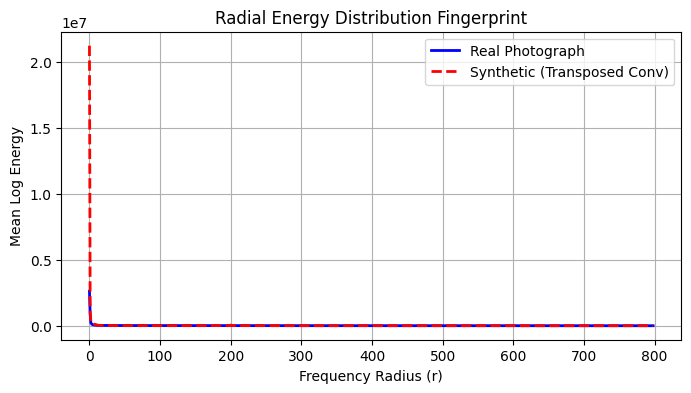

In [11]:
def radial_profile(fft_mag):
    h, w = fft_mag.shape
    cy, cx = h // 2, w // 2
    y, x = np.ogrid[-cy:h-cy, -cx:w-cx]
    r = np.sqrt(x**2 + y**2).astype(int)

    # Average energy in concentric rings
    tbin = np.bincount(r.ravel(), fft_mag.ravel())
    nr = np.bincount(r.ravel())
    radialprofile = tbin / np.maximum(nr, 1)
    return radialprofile[:min(cy, cx)]

# Calculate radial curves
curve_real = radial_profile(fft_real)
curve_ai = radial_profile(fft_ai)

# Plot 1D Profile
plt.figure(figsize=(8, 4))
plt.plot(curve_real, label="Real Photograph", color='blue', linewidth=2)
plt.plot(curve_ai, label="Synthetic (Transposed Conv)", color='red', linestyle='--', linewidth=2)
plt.xlabel("Frequency Radius (r)")
plt.ylabel("Mean Log Energy")
plt.title("Radial Energy Distribution Fingerprint")
plt.legend()
plt.grid(True)
plt.show()

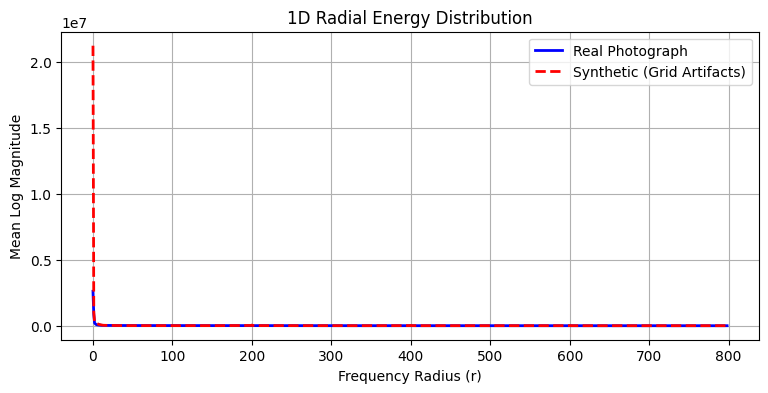

In [12]:
# --- Calculate 1D Radial Energy Profile ---
def radial_profile(fft_mag):
    h, w = fft_mag.shape
    cy, cx = h // 2, w // 2
    y, x = np.ogrid[-cy:h-cy, -cx:w-cx]
    r = np.sqrt(x**2 + y**2).astype(int)

    # Average energy in concentric rings out from center
    tbin = np.bincount(r.ravel(), fft_mag.ravel())
    nr = np.bincount(r.ravel())
    radial_profile = tbin / np.maximum(nr, 1)
    return radial_profile[:min(cy, cx)]

# Compute profiles from the FFT magnitudes
profile_real = radial_profile(fft_real)
profile_ai = radial_profile(fft_ai)

# Plot 1D Profile Comparison
plt.figure(figsize=(9, 4))
plt.plot(profile_real, label="Real Photograph", color='blue', linewidth=2)
plt.plot(profile_ai, label="Synthetic (Grid Artifacts)", color='red', linestyle='--', linewidth=2)
plt.xlabel("Frequency Radius (r)")
plt.ylabel("Mean Log Magnitude")
plt.title("1D Radial Energy Distribution")
plt.legend()
plt.grid(True)
plt.show()

he issue with the 1D Radial Energy plot comes down to plotting scale:

In the current plot, the Y-axis uses linear magnitude (10
7
 ), which compresses all high-frequency details (from radius 10 to 800) into a flat line along the X-axis (0.0). The massive DC offset/low-frequency center overwhelms the rest of the signal.

To fix this, the plot needs a logarithmic scale on the Y-axis (plt.yscale('log')).

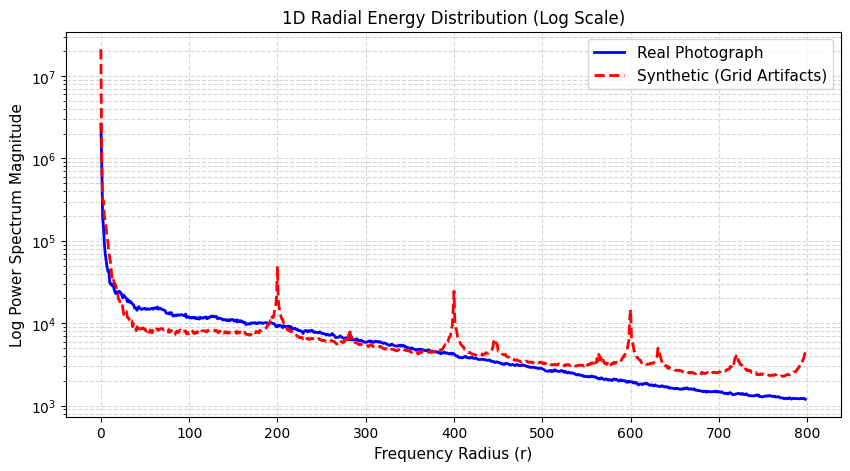

In [13]:
# --- Calculate 1D Radial Energy Profile ---
def radial_profile(fft_mag):
    h, w = fft_mag.shape
    cy, cx = h // 2, w // 2
    y, x = np.ogrid[-cy:h-cy, -cx:w-cx]
    r = np.sqrt(x**2 + y**2).astype(int)

    # Average energy in concentric rings out from center
    tbin = np.bincount(r.ravel(), fft_mag.ravel())
    nr = np.bincount(r.ravel())
    radial_profile = tbin / np.maximum(nr, 1)
    return radial_profile[:min(cy, cx)]

# Compute profiles from the FFT magnitudes
profile_real = radial_profile(fft_real)
profile_ai = radial_profile(fft_ai)

# Plot 1D Profile Comparison
plt.figure(figsize=(10, 5))
plt.plot(profile_real, label="Real Photograph", color='blue', linewidth=2)
plt.plot(profile_ai, label="Synthetic (Grid Artifacts)", color='red', linestyle='--', linewidth=2)

# KEY FIX: Set logarithmic scale for Y-axis to see mid and high frequencies
plt.yscale('log')

plt.xlabel("Frequency Radius (r)", fontsize=11)
plt.ylabel("Log Power Spectrum Magnitude", fontsize=11)
plt.title("1D Radial Energy Distribution (Log Scale)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()